# Retrieving Data

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as scp
import pandas as pd
import os
from matplotlib import colormaps

# Storing the Paths of my Assignment folder. Due to me working on a Windows Desktop PC at home and on a Linux Laptop in Uni, there are two different storing paths.
# To work easier, i comment the one im currently not using out. 
# IF YOU WANT TO USE THE CODE: chose one, and paste in your directory location.
path = r"C:\Users\Peter\Documents\Uni\Master\CRE 3\CRE3-Assignment-1\2026_Task_data"    # Windows Location
# path = "/home/pit/Uni/Master/CRE3/CRE3-Assignment-1/2026_Task_data"                     # Linux Location

# Creating a ist of all files in the above mentioned directory, which contains the data for the assignment.
exp_data = os.listdir(path)

# Storing the length/count of files in the directory, hence equaling the number of experiments
no_of_files = len(exp_data)

# creating empty lists to later store concentration, time and initials in
exp_conc = []                   # list of concentrations of all 6 species for all 6 Experiments, will be a List of 2D arrays
exp_time = []                   # List of Timestamps, where the concentrations got measured each experiment. Will be a List of 1D arrays
init_c_val = []                 # List of initial conzentrations for alle experiments. Will be a List of 1D arrays
for i in np.arange(0, no_of_files): # this is equal to: "for every whole number from 0 to maximum number of files, iterate the index"

    # iterate over all the csv-files and append them to the above initiated lists
    temp_dataframe = pd.read_csv(path + r'\Exp_res_' + str(i) + r'.csv') # Windows Version
    # temp_dataframe = pd.read_csv(path + r'/Exp_res' + i + r'.csv') # Linux Version

    exp_time.append(temp_dataframe.values.transpose()[0])       # the time values are all values from the first column, hence the [0]
    exp_conc.append(temp_dataframe.values.transpose()[1:])      # the concentration values are all values from the second column, hence the [1:]
    init_c_val.append(temp_dataframe.values.transpose()[1:, 0]) # the initial concentration value is the first value of the second column, hence the [1][0]

# Storing Lists in arrays for better Data manipulation
no_of_exp = len(init_c_val)
ExperimentalData = np.array([])                                 # Storage Container for the experimental Data in form of an array instead of a List
for i in range(no_of_exp):
    ExperimentalData = np.append(ExperimentalData, exp_conc[i])
    ''' 
    np.append appends the second given data (here: exp_conc[i]) 
    to the array given in the first argument (here: ExperimentalData) 
    and returns the expanded array. 
    To store it, we use ExperimentalData itself. 
    
    This gives an array of 1620 entrys flat as a 1D array. We can seperate them later by knowing, that there were 45 measurements for each experiment, and 6 species per experiment.
    This equals to 45(Measurements) x 6(Species) x 6(Experiments) concentrations, wich are in the following Order: [Exp0,ConcA],[Exp0,ConcB],...,[Exp1,ConcA],[Exp,1,ConcB],...,[Exp5,ConcF] (45 Elements in each Set) 
    '''
print(ExperimentalData[0:3])

[1.0113866  0.67591296 0.51402858]


# Plotting the Experimental Data raw

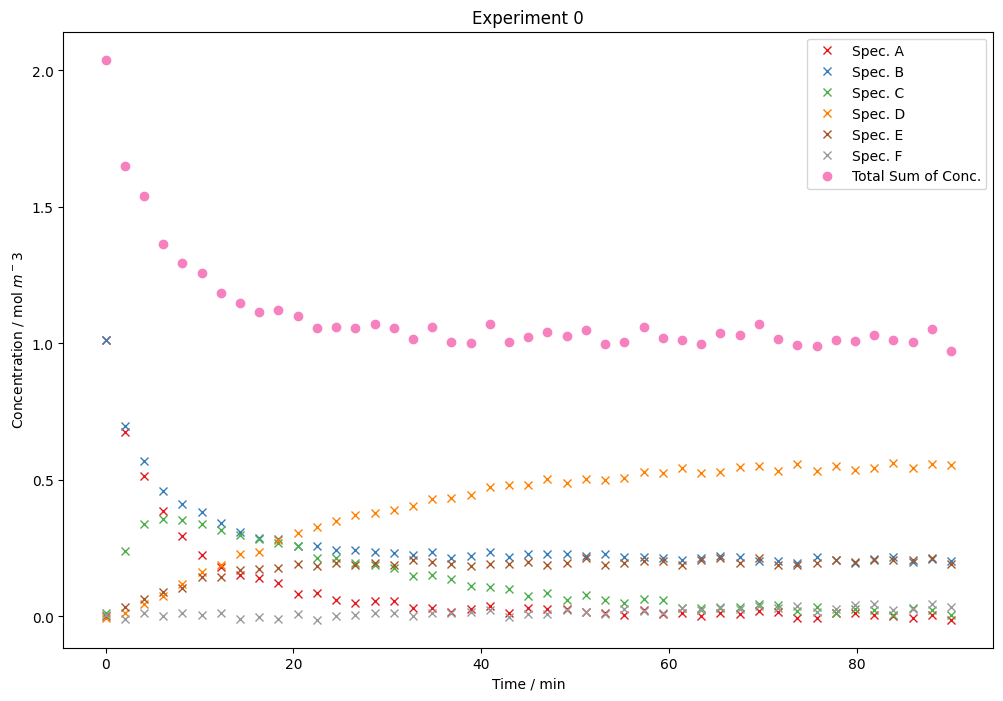

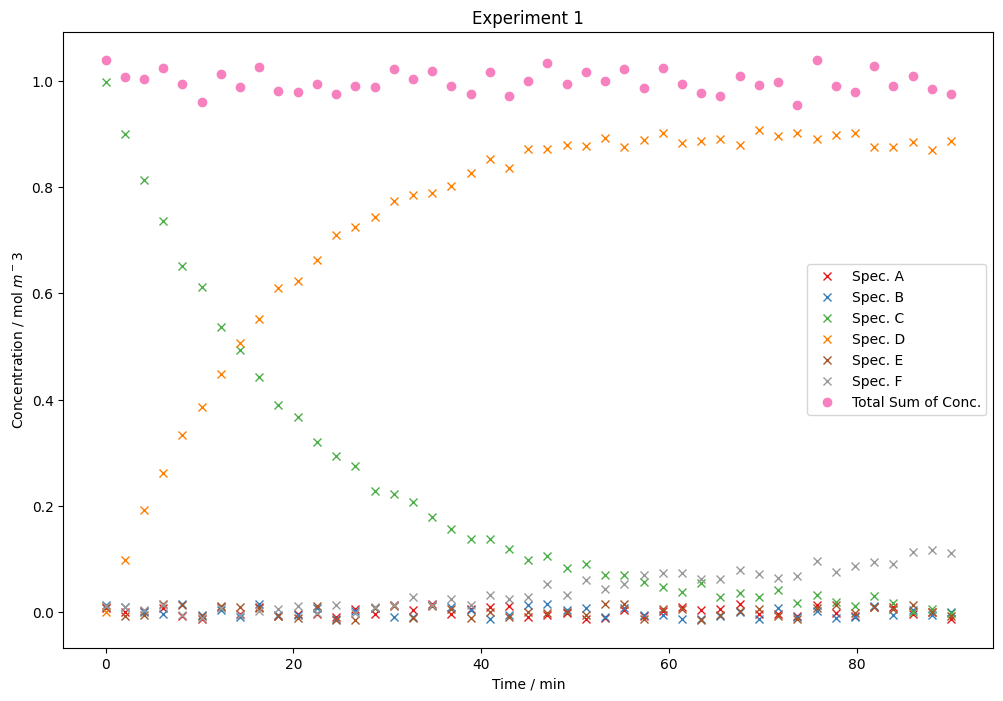

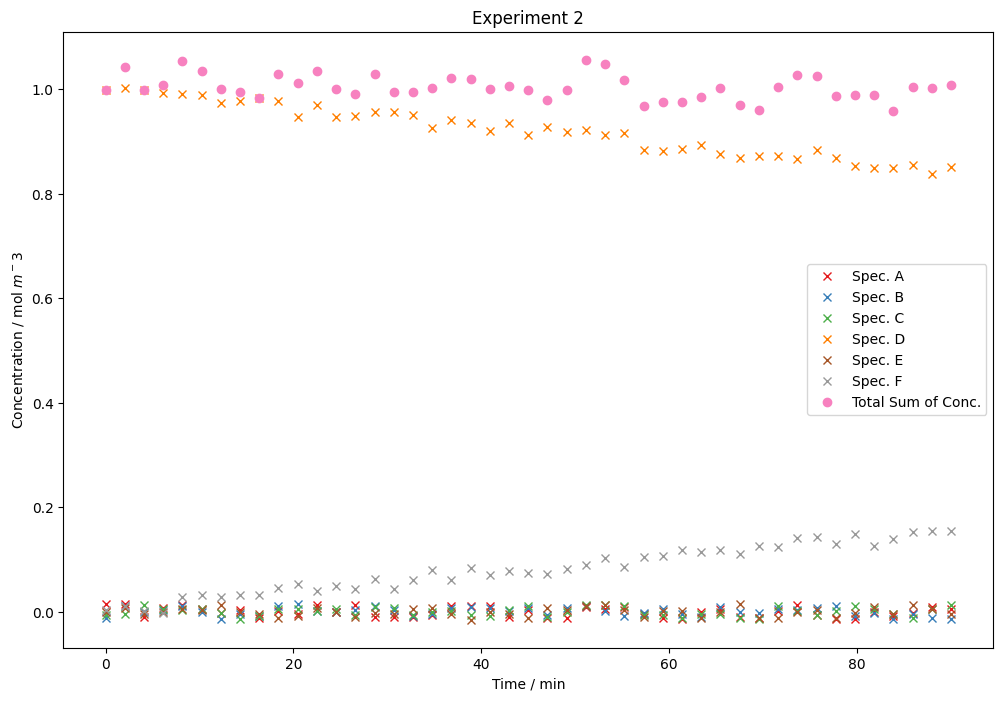

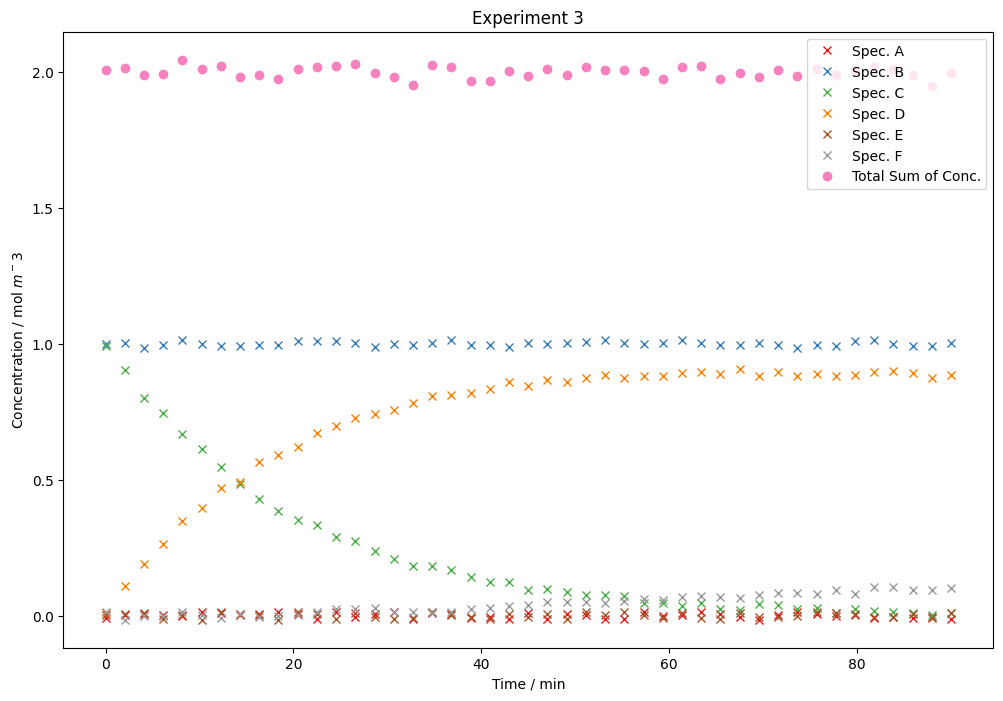

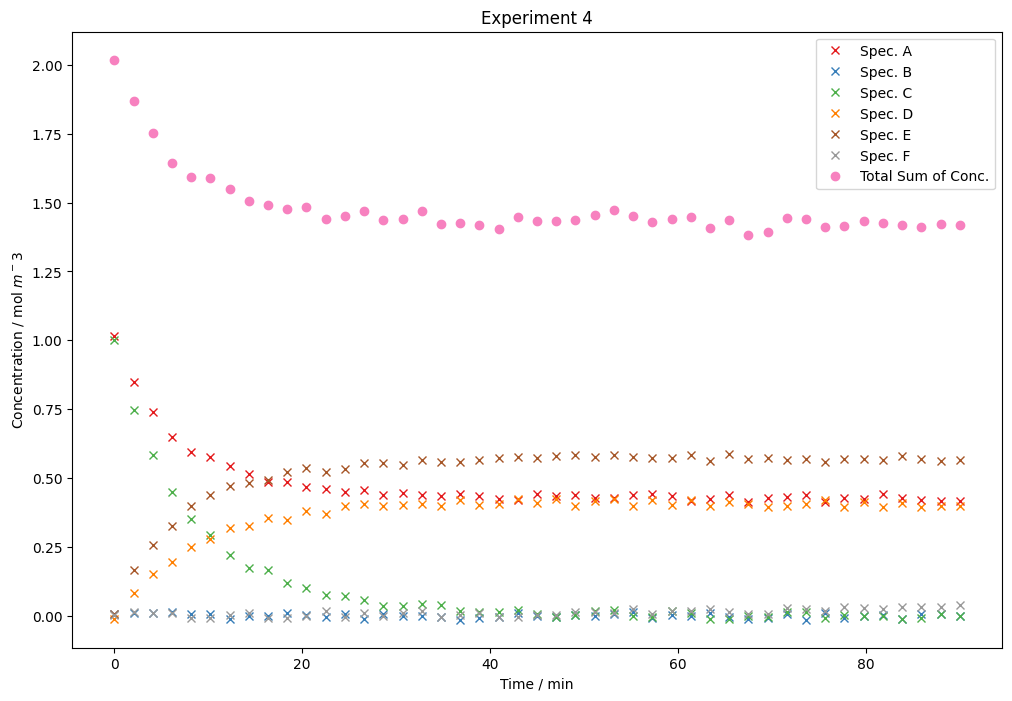

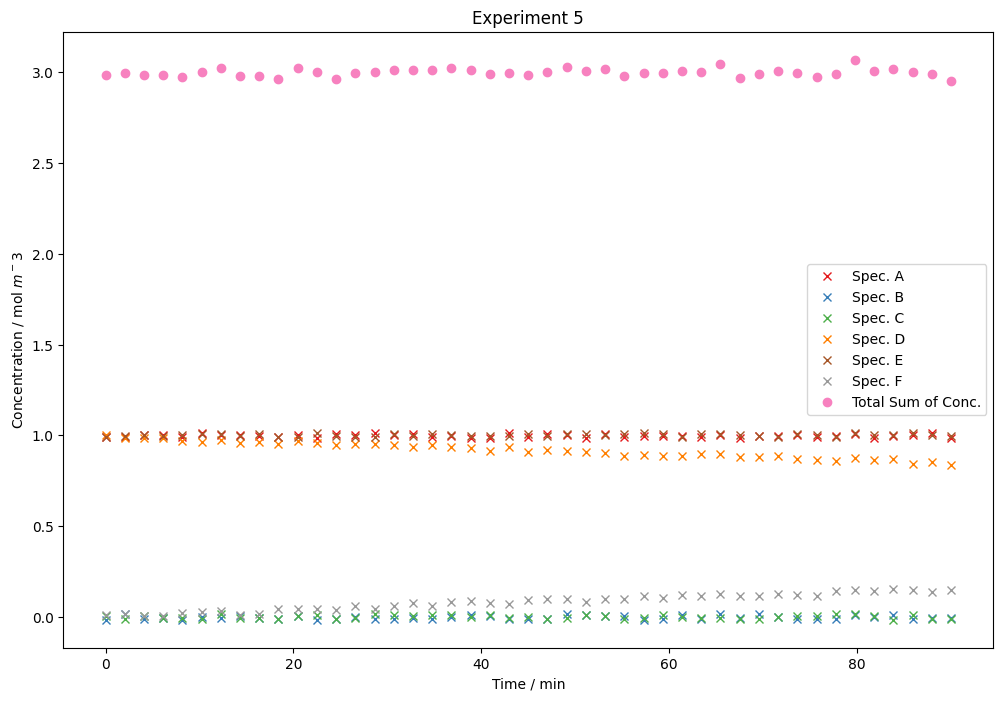

In [91]:
no_of_species = 6
speciescount = np.array(["A","B","C","D","E","F"])              # Naming Array for Legends in plotting
colors = colormaps.get_cmap('Set1')                            # Getting a colormap from library, personal preference and visibility
colordivider = np.array([0,0.15,0.3,0.5,0.7,0.99])               # Arrays with integers, to get the same colors for the same species in all diagrams

for i in range(no_of_exp):
    plt.subplots(figsize=(12,8))
    total_conc = np.zeros(45)
    for j in range(no_of_species):
        start = i * 270 + j *45                                         # starting point of each experimental series, 6 species times 45 measuring points equals 270 eperimental data points per experiment
        for p in range(45):
            total_conc[p] = total_conc[p] + ExperimentalData[start + p]
        plt.plot(exp_time[i], ExperimentalData[start : start + 45], 'x' , label = "Spec. " + speciescount[j], color = colors(colordivider[j]))
        plt.title("Experiment " + str(i))
        plt.xlabel("Time / min")
        plt.ylabel("Concentration / mol $m^-3$")
    
    plt.plot(exp_time[i], total_conc, 'o', label = 'Total Sum of Conc.', color = colors(0.8))
    plt.legend()
    plt.show()



# Deducing a Reaction Hypothesis:

The best Place to start is looking for Experiments with the least amount of converted species, because they enable us to make assumptions for Species Interactions.

### Experiment 5:

Experiment 5 shows Species D declining slightly, and an equal amount of Species F beeing formed. This leads to the hypothesis:
\begin{align}
    1D \rightarrow 1F
\end{align}

Also, there are the Species A and E as an Educt, wich are not consumed. Species B and C also show no accumulation over Time. This could mean that the Reactions 

\begin{align}
    xA \rightarrow yB \\
    xA \rightarrow yC \\
    xE \rightarrow yB \\
    xE \rightarrow yC \\
\end{align}
are not happening, wich we will use as our hypothesis for now.

### Experiment 2

Experiment 2 shows the same behavior as Experiment 5, but with just Species D as a possible Educt. This further strengthens the above formulated hypothesis, and shows, that the Reaction Paths 
\begin{equation}
    1A \rightarrow 1F
\end{equation}

\begin{equation}
    1E \rightarrow 1F
\end{equation}
from Experiment 5 are unlikely.

### Experiment 3:

Experiment 3 shows Species C beeing consumed, and forming Species D in a 1:1 Ratio. From 40 minutes on we can also see the Formation of Species F, wich is concurrent with our Hypothesis from Experiment 5. \
The newly formed Species D is slowly beeing consumed in the Formation of Species F
\begin{equation}
    1C \rightarrow 1D \rightarrow 1F
\end{equation}
In this Networking of Consecutive reactions, the Reaction from C to D seems to be much faster than the Reaction from D to F.

Also there is the Species B as a Educt, wich is not consumed. Therefor we hypothesize the following Reactions to be not taking place:
\begin{align}
    xB \rightarrow yX \\
    xB + yC \rightarrow XYZ 
\end{align}
Species B alone or in Combination with C has no reaction.

### Experiment 1

Experiment 1 shows the same Behavior for Species C,D and F as Experiment 3, but with only C as an Educt. This strenghtens all Hypothesis from Experiment 3.

### Experiment 4

Experiment 4 shows Species A and C as Educts, and Species D and E as formed Products. \
We know from before, that D can decay to Species F, but it is not distinguishable from general noise in this Experiment. B seems not to be formed at all.\
Species C gets fully consumed, Species A retains a concentration Level >0. \
This is also the first time the Total concentration changes, wich means some Rection has no 1:1 Ratio anymore. More Species is consumed than formed, the total Concentration goes from 2 $mol/m^3$ to about 1.5 $mol/m^3$.

We know from Experiment 5, that the Combination of Species A and E, A and D or Species E and D produce no Reaction. Therefor we can hypothesize, that E is not part of any further reaction and just gets formed. 

Experiment 3 and 1 showed a 1:1 Ratio for the Formation of D from C, yet here only half as much D as consumed C is formed. Species C must therefor be involved in the Formation of E. We hypothesize the following reactions happening here:

\begin{align}
    1A + 1C \rightarrow 1E\\
    1C  \rightarrow 1D\\
    1D \rightarrow 1F (slow)
\end{align}

### Experiment 0

Experiment 0 is the first Time B gets consumed, and the only time it is existing besides Species A. Therefor we can formulate the Hypothesis, that A and B together react to something.\ 
Because it has the highest starting Formation Speed, it is reasonable to think, C is beeing formed. The Ration would be 2:1.
\begin{equation}
    1A + 1B \rightarrow 1C
\end{equation}
C is beeing formed and after a Peak starts beeing consumed. This is most likely the Formation into D, seen in Experiments 1 and 3. \
Also C is involved in the Formation of E with Species A, wich explains the total Consumation of A, while B reatins a concentration >0.

## Summary 

The standing Hypothesis predicts the follwing Reaction Network:
\begin{align}
    1A + 1C \rightarrow 1 E\\
    1A + 1B \rightarrow 1 C\\
    1C \rightarrow 1 D\\
    1D \rightarrow 1 F\\
\end{align}

The Reaction from D to F is very slow. We can also conclude, that Reaction 1 is faster than Reaction 3 (seen in Experiment 4).